- PM2.5 refers to fine particulate matter micrometers in diameter, posing severe health risks because they penetrate deep into lungs and enter the bloodstream. Primarily caused by combustion (vehicles, power plants, industry, fires), these particles cause 4+ million annual deaths, driving heart/lung diseases. WHO recommends an annual limit of 5 
- This hourly data set contains the PM2.5 data of US Embassy in Beijing. Meanwhile, meteorological data from Beijing Capital International Airport are also included.


import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv"

response = requests.get(url)

with open("PRSA_data.csv", "wb") as f:
    f.write(response.content)

In [1]:
import pandas as pd

df=pd.read_csv("PRSA_data.csv")

print(df.shape)       # (43824, 13)
print(df.head())
print(df.isnull().sum())  # PM2.5 has ~2000 missing values to handle

(43824, 13)
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0
No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64


| Attribute | Full Name                 | Purpose / Description                                                                                                                      |
| --------- | ------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------ |
| **No**    | Record Number             | Unique identifier for each hourly observation (sequential index)                                                                           |
| **year**  | Year                      | Calendar year of observation (2010–2014) — for temporal analysis and train/test splitting                                                  |
| **month** | Month                     | Month of year (1–12) — seasonal pattern extraction                                                                                         |
| **day**   | Day                       | Day of month (1–31) — date component for datetime construction                                                                             |
| **hour**  | Hour                      | Hour of day (0–23) — captures diurnal pollution patterns                                                                                   |
| **pm2.5** | PM2.5 Concentration       | **Target variable** — Fine particulate matter ≤2.5 micrometers (µg/m³). Primary air pollutant indicator, hazardous to health when elevated |
| **DEWP**  | Dew Point Temperature     | Temperature at which air becomes saturated (°C). Indicates humidity levels and atmospheric moisture                                        |
| **TEMP**  | Temperature               | Ambient air temperature (°C). Affects chemical reactions and pollutant dispersion                                                          |
| **PRES**  | Atmospheric Pressure      | Barometric pressure (hPa). Influences air movement, wind patterns, and pollutant accumulation                                              |
| **cbwd**  | Combined Wind Direction   | Categorical wind direction (N, NE, E, SE, S, SW, W, NW). Determines pollution source origins and dispersion paths                          |
| **Iws**   | Cumulative Wind Speed     | Aggregated wind speed (m/s). Higher speeds disperse pollutants; calm conditions trap them                                                  |
| **Is**    | Cumulative Snowfall Hours | Hours of accumulated snow. Snow can scavenge particles from air but also trap pollutants near ground                                       |
| **Ir**    | Cumulative Rainfall Hours | Hours of accumulated rain. Rain washes out particulates (wet deposition), reducing PM2.5                                                   |


# Data Preprocessing

## Imported Packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import StackingRegressor

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  str    
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,12651.043435,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,1.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,21912.500000,2012.000000,7.000000,16.000000,11.500000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,32868.250000,2013.000000,10.000000,23.000000,17.250000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


### Handling Missing values
- There is **2067** `(0.047%)` missing values in feature `PM2.5` (Target Variable) 

In [4]:
df.isnull().sum()

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [5]:
df.head(30)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0
5,6,2010,1,1,5,NaN,-19,-10.0,1017.0,NW,16.10,0,0
6,7,2010,1,1,6,NaN,-19,-9.0,1017.0,NW,19.23,0,0
7,8,2010,1,1,7,NaN,-19,-9.0,1017.0,NW,21.02,0,0
8,9,2010,1,1,8,NaN,-19,-9.0,1017.0,NW,24.15,0,0
9,10,2010,1,1,9,NaN,-20,-8.0,1017.0,NW,27.28,0,0


In [6]:
# ── Step 3: Handle Missing Values — Gap-Aware Strategy ──

print("Before:", df.shape)
print(f"Total missing pm2.5: {df['pm2.5'].isnull().sum()}")

# Step 1: Drop the first 24 rows (series start — nothing to fill from)
df = df.iloc[24:].reset_index(drop=True)
print(" Dropped the first 24 rows (series start — nothing to fill from)")

# Step 2: Find consecutive missing blocks and label their sizes
is_null      = df['pm2.5'].isnull()
gap_id       = (is_null != is_null.shift()).cumsum()
gap_sizes    = is_null.groupby(gap_id).transform('sum')

# Step 3: Decide by threshold
THRESHOLD = 24   # hours — drop blocks longer than this

# Mark rows belonging to large gaps
large_gap_rows = is_null & (gap_sizes > THRESHOLD)
dropped_large  = large_gap_rows.sum()

# Drop large gap rows entirely
df = df[~large_gap_rows].reset_index(drop=True)

# Step 4: Interpolate remaining small gaps (≤ 24 hours)
small_gaps_before = df['pm2.5'].isnull().sum()
df['pm2.5'] = df['pm2.5'].interpolate(method='linear',
                                        limit=THRESHOLD,
                                        limit_direction='forward')
small_gaps_after = df['pm2.5'].isnull().sum()

print(f"\n  Large gaps (>{THRESHOLD}h) → {dropped_large} rows dropped")
print(f"  Small gaps (≤{THRESHOLD}h) → {small_gaps_before - small_gaps_after} rows interpolated")
print(f"  Remaining nulls           → {df['pm2.5'].isnull().sum()}")
print(f"\nAfter cleaning: {df.shape}")

Before: (43824, 13)
Total missing pm2.5: 2067
 Dropped the first 24 rows (series start — nothing to fill from)

  Large gaps (>24h) → 1341 rows dropped
  Small gaps (≤24h) → 702 rows interpolated
  Remaining nulls           → 0

After cleaning: (42459, 13)


In [7]:
df

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0
1,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0
3,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0
4,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
42454,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0
42455,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0
42456,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0
42457,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0


## Feature Engineering


In [8]:
df['cbwd'].value_counts()

cbwd
SE    14851
NW    13669
cv     9102
NE     4837
Name: count, dtype: int64

##### wind_pressure = Iws × PRES (Wind Speed × Pressure)

| Why It Matters              | Explanation                                                                 |
| --------------------------- | --------------------------------------------------------------------------- |
| **Trapping vs. Dispersion** | High pressure + low wind = pollution trapping (temperature inversion layer) |
| **Clearing events**         | High pressure + high wind = pollution pushed out by strong winds            |
| **Low pressure systems**    | Usually brings precipitation and wind — clears pollution                    |

| Scenario        | Iws | PRES | wind\_pressure | Pollution Impact       |
| --------------- | --- | ---- | -------------- | ---------------------- |
| Stagnant air    | 1   | 1030 | 1030           | 🔴 High accumulation   |
| Strong winds    | 10  | 1000 | 10000          | 🟢 Disperses pollution |
| Moderate breeze | 5   | 1020 | 5100           | 🟡 Moderate effect     |
---------
##### temp_dewp_diff = TEMP − DEWP

| Scenario    | TEMP | DEWP | temp\_dewp\_diff | Condition                         |
| ----------- | ---- | ---- | ---------------- | --------------------------------- |
| Dry, clear  | 25°C | 5°C  | 20°C             | Low humidity, dispersed particles |
| Humid, hazy | 25°C | 23°C | 2°C              | High humidity, swollen particles  |

---------
##### wind direction `One hot encoding`

- SE
- NW
- cv **Calm and Variable wind**
- NE


| wind_NW   | wind_SE  | wind_cv | 
| -------  | -------- | ------- | 
|  1       |   0      |   0     |   
|  0       |   1      |   0     |   
|  0       |   0      |   1     |   
|  1       |   0      |   0     |   
|  0       |   0      |   0     |   


In [9]:
# 3. TEMP_DEWP_DIFF — Numeric interaction
df['temp_dewp_diff'] = df['TEMP'] - df['DEWP']

# 4. WIND_PRESSURE — Numeric interaction  a
df['wind_pressure'] = df['Iws'] * df['PRES']

# 5. WIND DIRECTION — ONE-HOT ENCODING (nominal, no order)
# Drop first to avoid multicollinearity (n-1 dummy variables)
wind_dummies = pd.get_dummies(df['cbwd'], prefix='wind', drop_first=True)
df = pd.concat([df, wind_dummies], axis=1)

print("Wind direction one-hot columns:", wind_dummies.columns.tolist())

Wind direction one-hot columns: ['wind_NW', 'wind_SE', 'wind_cv']


In [10]:
df

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,temp_dewp_diff,wind_pressure,wind_NW,wind_SE,wind_cv
0,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0,12.0,1825.80,False,True,False
1,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0,11.0,2733.60,False,True,False
2,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0,6.0,3644.97,False,True,False
3,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0,2.0,5477.92,False,True,False
4,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0,2.0,6387.50,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42454,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0,21.0,239856.98,True,False,False
42455,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0,19.0,245864.52,True,False,False
42456,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0,19.0,250951.80,True,False,False
42457,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0,18.0,255108.48,True,False,False


In [11]:
df_2=df.copy()

In [12]:
df_2['pm2.5'].describe()

count    42459.000000
mean        98.612673
std         91.932542
min          0.000000
25%         29.000000
50%         72.000000
75%        137.000000
max        994.000000
Name: pm2.5, dtype: float64

<Axes: >

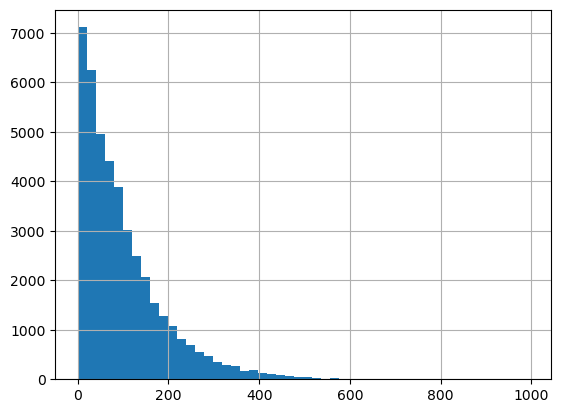

In [13]:
df_2['pm2.5'].hist(bins=50)

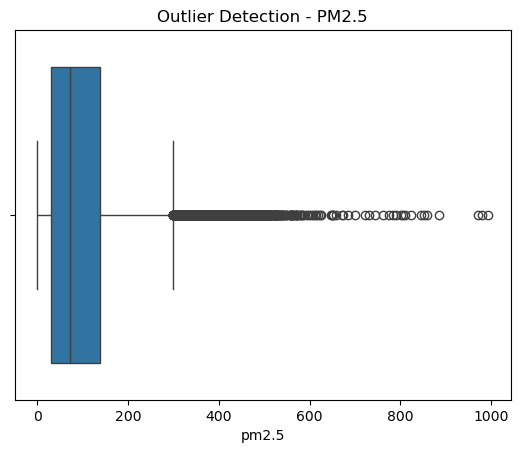

Number of outliers: 1796


In [14]:
sns.boxplot(x=df_2['pm2.5'])
plt.title("Outlier Detection - PM2.5")
plt.show()
Q1 = df_2['pm2.5'].quantile(0.25)
Q3 = df_2['pm2.5'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_2[(df_2['pm2.5'] < lower) | (df_2['pm2.5'] > upper)]

print("Number of outliers:", len(outliers))

## Apply Log Transformation
- To get more summetric shape

In [15]:
df_2['pm2.5'] = np.log1p(df_2['pm2.5'])

<Axes: >

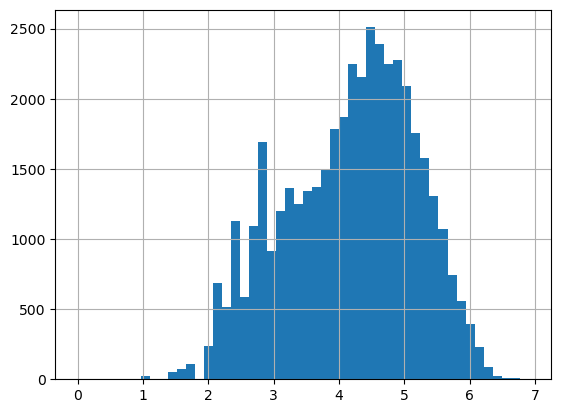

In [16]:
df_2['pm2.5'].hist(bins=50)

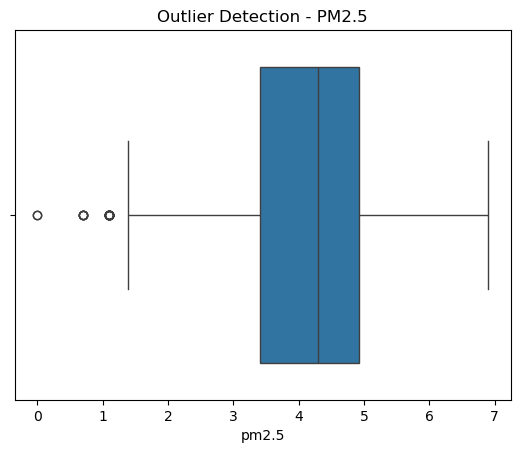

Number of outliers: 31


In [17]:
sns.boxplot(x=df_2['pm2.5'])
plt.title("Outlier Detection - PM2.5")
plt.show()
Q1 = df_2['pm2.5'].quantile(0.25)
Q3 = df_2['pm2.5'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_2[(df_2['pm2.5'] < lower) | (df_2['pm2.5'] > upper)]

print("Number of outliers:", len(outliers))

Outliers were identified using the IQR method and visualized using boxplots. After log transformation, only a small number of outliers remained, indicating reduced skewness. Since these represent real-world extreme pollution events and constitute a negligible proportion of the dataset, they were retained.

#### Before transformation:

- Outliers were numerically large (1796) `0.422%`

#### After transformation:

- Outliers are statistically controlled (31) `0.0007%`

In [18]:
df_2.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,temp_dewp_diff,wind_pressure,wind_NW,wind_SE,wind_cv
0,25,2010,1,2,0,4.867534,-16,-4.0,1020.0,SE,1.79,0,0,12.0,1825.80,False,True,False
1,26,2010,1,2,1,5.003946,-15,-4.0,1020.0,SE,2.68,0,0,11.0,2733.60,False,True,False
2,27,2010,1,2,2,5.075174,-11,-5.0,1021.0,SE,3.57,0,0,6.0,3644.97,False,True,False
3,28,2010,1,2,3,5.204007,-7,-5.0,1022.0,SE,5.36,1,0,2.0,5477.92,False,True,False
4,29,2010,1,2,4,4.934474,-7,-5.0,1022.0,SE,6.25,2,0,2.0,6387.50,False,True,False


In [19]:
# lag features (very powerful)
df_2['pm2.5_lag1'] = df_2['pm2.5'].shift(1)
df_2['pm2.5_lag2'] = df_2['pm2.5'].shift(2)
df_2['pm2.5_roll_mean'] = df_2['pm2.5'].shift(1).rolling(3).mean()
df_2 = df_2.dropna()
df_2

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,...,Is,Ir,temp_dewp_diff,wind_pressure,wind_NW,wind_SE,wind_cv,pm2.5_lag1,pm2.5_lag2,pm2.5_roll_mean
3,28,2010,1,2,3,5.204007,-7,-5.0,1022.0,SE,...,1,0,2.0,5477.92,False,True,False,5.075174,5.003946,4.982218
4,29,2010,1,2,4,4.934474,-7,-5.0,1022.0,SE,...,2,0,2.0,6387.50,False,True,False,5.204007,5.075174,5.094376
5,30,2010,1,2,5,4.700480,-7,-6.0,1022.0,SE,...,3,0,1.0,7297.08,False,True,False,4.934474,5.204007,5.071218
6,31,2010,1,2,6,4.663439,-7,-6.0,1023.0,SE,...,4,0,1.0,9135.39,False,True,False,4.700480,4.934474,4.946320
7,32,2010,1,2,7,4.828314,-7,-5.0,1024.0,SE,...,0,0,2.0,10977.28,False,True,False,4.663439,4.700480,4.766131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42454,43820,2014,12,31,19,2.197225,-23,-2.0,1034.0,NW,...,0,0,21.0,239856.98,True,False,False,2.397895,2.302585,2.299235
42455,43821,2014,12,31,20,2.397895,-22,-3.0,1034.0,NW,...,0,0,19.0,245864.52,True,False,False,2.197225,2.397895,2.299235
42456,43822,2014,12,31,21,2.397895,-22,-3.0,1034.0,NW,...,0,0,19.0,250951.80,True,False,False,2.397895,2.197225,2.331005
42457,43823,2014,12,31,22,2.197225,-22,-4.0,1034.0,NW,...,0,0,18.0,255108.48,True,False,False,2.397895,2.397895,2.331005


| Feature                     | Encoding    | Type            | Purpose             |
| --------------------------- | ----------- | --------------- | ------------------- |
| `year`                      | None        | Numeric         | Temporal trend      |
| `month`                     | None        | Numeric         | Seasonal cycle      |
| `day`                       | None        | Numeric         | Date component      |
| `hour`                      | None        | Numeric         | Diurnal pattern     |
| `DEWP`                      | None        | Numeric         | Humidity            |
| `TEMP`                      | None        | Numeric         | Temperature         |
| `PRES`                      | None        | Numeric         | Pressure            |
| `Iws`                       | None        | Numeric         | Wind speed          |
| `Is`                        | None        | Numeric         | Snow                |
| `Ir`                        | None        | Numeric         | Rain                |
| `temp_dewp_diff`            | Engineered  | Numeric         | Humidity physics    |
| `wind_pressure`             | Engineered  | Numeric         | Atmosphere dynamics |
| `wind_NW` through `wind_cv` | One-Hot     | Binary (4 cols) | Direction effects   |
| `pm2.5_lag1`                | None        | Numeric         | PM2.5 Value one hour ago |
| `pm2.5_lag2`                | None        | Numeric         | PM2.5 Value two hour ago |
| `pm2.5_roll_mean`                | None        | Numeric         | Mean of PM2.5 Value of last 3 hours  |


In [20]:
# Select all features for correlation (exclude original categorical and datetime)
feature_cols = ['year', 'month', 'day', 'hour', 'DEWP', 'TEMP', 'PRES', 
                'Iws', 'Is', 'Ir',  
                'temp_dewp_diff', 'wind_pressure','pm2.5_lag1','pm2.5_lag2','pm2.5_roll_mean']

In [21]:
# Calculate correlations with pm2.5
correlations = df_2[feature_cols + ['pm2.5']].corr()['pm2.5'].drop('pm2.5')
correlations = correlations.sort_values(key=abs, ascending=False)

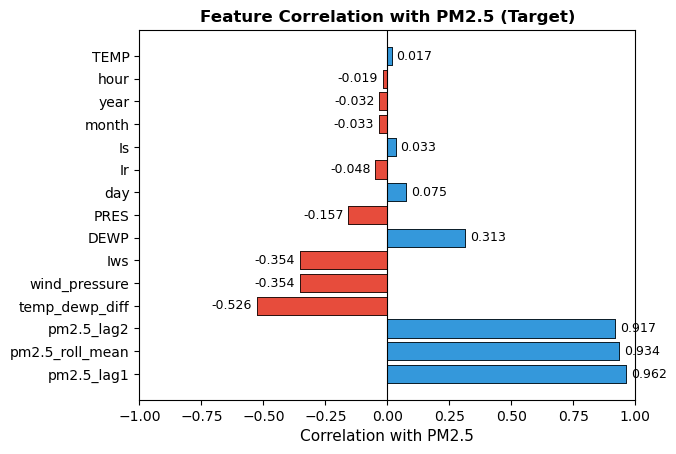

In [22]:


colors = ['#e74c3c' if x < 0 else '#3498db' for x in correlations.values]
plt.barh(correlations.index, correlations.values, color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Correlation with PM2.5', fontsize=11)
plt.title('Feature Correlation with PM2.5 (Target)', fontsize=12, fontweight='bold')
plt.xlim(-1, 1)

bars = plt.barh(correlations.index, correlations.values, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, correlations.values):
    plt.text(val + 0.02 if val >= 0 else val - 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', ha='left' if val >= 0 else 'right', va='center', fontsize=9)


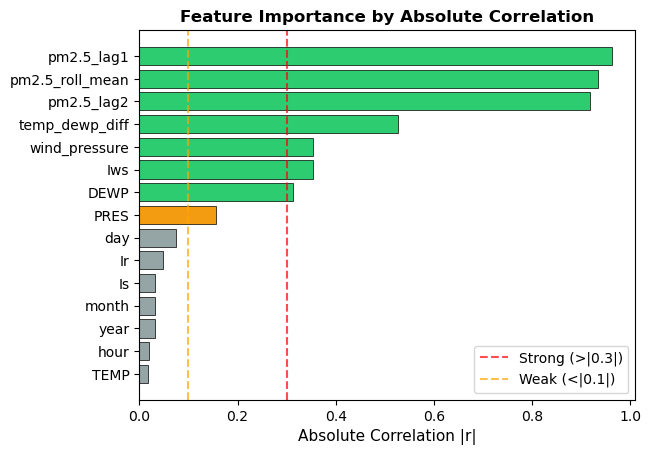

In [23]:
abs_corr = correlations.abs().sort_values(ascending=True)
colors2 = ['#2ecc71' if x > 0.3 else '#f39c12' if x > 0.1 else '#95a5a6' for x in abs_corr.values]
plt.barh(abs_corr.index, abs_corr.values, color=colors2, edgecolor='black', linewidth=0.5)
plt.xlabel('Absolute Correlation |r|', fontsize=11)
plt.title('Feature Importance by Absolute Correlation', fontsize=12, fontweight='bold')
plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.7, label='Strong (>|0.3|)')
plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Weak (<|0.1|)')
plt.legend(loc='lower right')
plt.show()

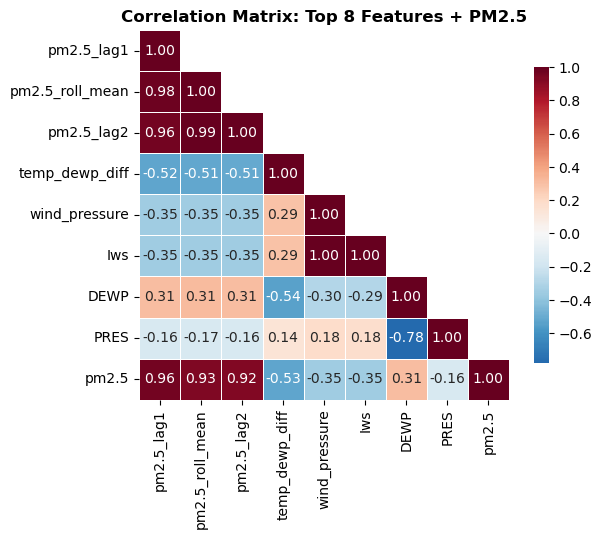

In [24]:
import numpy as np

top_features = correlations.abs().nlargest(8).index.tolist() + ['pm2.5']
corr_matrix = df_2[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0,  square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Top 8 Features + PM2.5', fontsize=12, fontweight='bold')
plt.show()

In [25]:
df_2

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,...,Is,Ir,temp_dewp_diff,wind_pressure,wind_NW,wind_SE,wind_cv,pm2.5_lag1,pm2.5_lag2,pm2.5_roll_mean
3,28,2010,1,2,3,5.204007,-7,-5.0,1022.0,SE,...,1,0,2.0,5477.92,False,True,False,5.075174,5.003946,4.982218
4,29,2010,1,2,4,4.934474,-7,-5.0,1022.0,SE,...,2,0,2.0,6387.50,False,True,False,5.204007,5.075174,5.094376
5,30,2010,1,2,5,4.700480,-7,-6.0,1022.0,SE,...,3,0,1.0,7297.08,False,True,False,4.934474,5.204007,5.071218
6,31,2010,1,2,6,4.663439,-7,-6.0,1023.0,SE,...,4,0,1.0,9135.39,False,True,False,4.700480,4.934474,4.946320
7,32,2010,1,2,7,4.828314,-7,-5.0,1024.0,SE,...,0,0,2.0,10977.28,False,True,False,4.663439,4.700480,4.766131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42454,43820,2014,12,31,19,2.197225,-23,-2.0,1034.0,NW,...,0,0,21.0,239856.98,True,False,False,2.397895,2.302585,2.299235
42455,43821,2014,12,31,20,2.397895,-22,-3.0,1034.0,NW,...,0,0,19.0,245864.52,True,False,False,2.197225,2.397895,2.299235
42456,43822,2014,12,31,21,2.397895,-22,-3.0,1034.0,NW,...,0,0,19.0,250951.80,True,False,False,2.397895,2.197225,2.331005
42457,43823,2014,12,31,22,2.197225,-22,-4.0,1034.0,NW,...,0,0,18.0,255108.48,True,False,False,2.397895,2.397895,2.331005


In [26]:
df_2.columns.to_list()

['No',
 'year',
 'month',
 'day',
 'hour',
 'pm2.5',
 'DEWP',
 'TEMP',
 'PRES',
 'cbwd',
 'Iws',
 'Is',
 'Ir',
 'temp_dewp_diff',
 'wind_pressure',
 'wind_NW',
 'wind_SE',
 'wind_cv',
 'pm2.5_lag1',
 'pm2.5_lag2',
 'pm2.5_roll_mean']

## Removing unwanted features

In [27]:
df_2.drop(['No','cbwd'], axis=1, inplace=True)

##### Import Features
- DEWP
- TEMP
- PRES
- Iws
- temp_dewp_diff
- wind_pressure
- wind_* columns

These actually influence PM2.5

In [28]:
df_2.columns

Index(['year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws',
       'Is', 'Ir', 'temp_dewp_diff', 'wind_pressure', 'wind_NW', 'wind_SE',
       'wind_cv', 'pm2.5_lag1', 'pm2.5_lag2', 'pm2.5_roll_mean'],
      dtype='str')

In [29]:
df_2.isnull().sum()

year               0
month              0
day                0
hour               0
pm2.5              0
DEWP               0
TEMP               0
PRES               0
Iws                0
Is                 0
Ir                 0
temp_dewp_diff     0
wind_pressure      0
wind_NW            0
wind_SE            0
wind_cv            0
pm2.5_lag1         0
pm2.5_lag2         0
pm2.5_roll_mean    0
dtype: int64

In [30]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 42456 entries, 3 to 42458
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             42456 non-null  int64  
 1   month            42456 non-null  int64  
 2   day              42456 non-null  int64  
 3   hour             42456 non-null  int64  
 4   pm2.5            42456 non-null  float64
 5   DEWP             42456 non-null  int64  
 6   TEMP             42456 non-null  float64
 7   PRES             42456 non-null  float64
 8   Iws              42456 non-null  float64
 9   Is               42456 non-null  int64  
 10  Ir               42456 non-null  int64  
 11  temp_dewp_diff   42456 non-null  float64
 12  wind_pressure    42456 non-null  float64
 13  wind_NW          42456 non-null  bool   
 14  wind_SE          42456 non-null  bool   
 15  wind_cv          42456 non-null  bool   
 16  pm2.5_lag1       42456 non-null  float64
 17  pm2.5_lag2       42456 

In [31]:
df_2[['wind_NW','wind_SE','wind_cv']] = df_2[['wind_NW','wind_SE','wind_cv']].astype(int)
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 42456 entries, 3 to 42458
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             42456 non-null  int64  
 1   month            42456 non-null  int64  
 2   day              42456 non-null  int64  
 3   hour             42456 non-null  int64  
 4   pm2.5            42456 non-null  float64
 5   DEWP             42456 non-null  int64  
 6   TEMP             42456 non-null  float64
 7   PRES             42456 non-null  float64
 8   Iws              42456 non-null  float64
 9   Is               42456 non-null  int64  
 10  Ir               42456 non-null  int64  
 11  temp_dewp_diff   42456 non-null  float64
 12  wind_pressure    42456 non-null  float64
 13  wind_NW          42456 non-null  int64  
 14  wind_SE          42456 non-null  int64  
 15  wind_cv          42456 non-null  int64  
 16  pm2.5_lag1       42456 non-null  float64
 17  pm2.5_lag2       42456 

# Model Building

### Import packages and make a evaluation functiond

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,make_scorer
s
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import optuna
from sklearn.model_selection import TimeSeriesSplit



In [33]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Convert back from log scale
    y_pred_actual = np.expm1(y_pred)
    y_test_actual = np.expm1(y_test)
    
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual, y_pred_actual)
    
    return mse, rmse, r2

#### Percentage Distribution of data according to year

In [34]:
year_counts = df_2['year'].value_counts().sort_index()
year_percent = (year_counts / len(df_2)) * 100

print(pd.DataFrame({
    'Count': year_counts,
    'Percentage (%)': year_percent
}))

      Count  Percentage (%)
year                       
2010   8204       19.323535
2011   8349       19.665065
2012   8383       19.745148
2013   8760       20.633126
2014   8760       20.633126


- Here we are going to split the data according to time.
- `train_data` dataset from year 2010 to 2013 (about 80% of all data)
- `test_data` dataset from year 2014 (about 20% of all data)

In [35]:
train= df_2[df_2['year'] <= 2013]
test = df_2[df_2['year'] == 2014]

In [36]:
X_train = train.drop('pm2.5', axis=1)
y_train = train['pm2.5']



X_test = test.drop('pm2.5', axis=1)
y_test = test['pm2.5']

### Hyperparameter tuning

| Model             | Best Search Method    |
| ----------------- | --------------------- |
| Linear Regression | No tuning needed      |
| Decision Tree     | Grid Search           |
| Random Forest     | Randomized Search     |
| XGBoost           | Optuna (best choice)  |
| Stacking          | Use tuned base models |


#### Decision Tree Hyperparamet tuning

In [37]:
tscv = TimeSeriesSplit(n_splits=5)

In [38]:
dt_params = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeRegressor(random_state=42)

grid_dt = GridSearchCV(dt, dt_params, cv=tscv, scoring='neg_root_mean_squared_error')

grid_dt.fit(X_train, y_train)

print("Best DT Params:", grid_dt.best_params_)

Best DT Params: {'max_depth': 5, 'min_samples_split': 2}


#### Random Forest Regressor Hyperparameter Tuning

In [39]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

random_rf = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

random_rf.fit(X_train, y_train)

print("Best RF Params:", random_rf.best_params_)

Best RF Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': None}


#### XGBoost Hyperparameter tuning 

In [40]:
from sklearn.model_selection import cross_val_score
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    
    model = XGBRegressor(**params, random_state=42)
    
    # Cross-validation (on log scale)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=tscv,
        scoring='neg_mean_squared_error'
    )
    
    rmse = np.sqrt(-scores.mean())
    
    return rmse

In [41]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("Best XGB Params:", study.best_params)


[I 2026-04-02 13:06:10,274] A new study created in memory with name: no-name-399da3c9-6d47-4645-80a2-5c82339b585b
[I 2026-04-02 13:06:11,162] Trial 0 finished with value: 0.28099904573428397 and parameters: {'n_estimators': 112, 'max_depth': 6, 'learning_rate': 0.023765954050335873, 'subsample': 0.6789983970072997, 'colsample_bytree': 0.9295305231878133}. Best is trial 0 with value: 0.28099904573428397.
[I 2026-04-02 13:06:11,657] Trial 1 finished with value: 0.26564768583377324 and parameters: {'n_estimators': 105, 'max_depth': 4, 'learning_rate': 0.08888908724065286, 'subsample': 0.6785848157961372, 'colsample_bytree': 0.8709696170505555}. Best is trial 1 with value: 0.26564768583377324.
[I 2026-04-02 13:06:12,423] Trial 2 finished with value: 0.26977011513764343 and parameters: {'n_estimators': 126, 'max_depth': 6, 'learning_rate': 0.06725248390415801, 'subsample': 0.842390567405587, 'colsample_bytree': 0.9003733476267377}. Best is trial 1 with value: 0.26564768583377324.
[I 2026-04

Best XGB Params: {'n_estimators': 82, 'max_depth': 4, 'learning_rate': 0.08659868296562834, 'subsample': 0.9135816968645174, 'colsample_bytree': 0.8067720253469616}


### Building the models using the best hyperparameters


In [42]:
best_dt = DecisionTreeRegressor(**grid_dt.best_params_, random_state=42)
best_rf = RandomForestRegressor(**random_rf.best_params_, random_state=42)
best_xgb = XGBRegressor(**study.best_params,random_state=42)
best_lr = LinearRegression()

best_dt.fit(X_train, y_train)
best_rf.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8067720253469616
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:


stack_model = StackingRegressor(
    estimators=[
        ('lr', best_lr),
        ('dt', best_dt),
        ('xgb', best_xgb)
    ],
    final_estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    cv=5
)

stack_model.fit(X_train, y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,RandomForestR...ndom_state=42)
,cv,5
,n_jobs,None
,passthrough,False
,verbose,0
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
lr_mse, lr_rmse, lr_r2 = evaluate_model(best_lr, X_train, y_train, X_test, y_test)
dt_mse, dt_rmse, dt_r2 = evaluate_model(best_dt, X_train, y_train, X_test, y_test)
rf_mse, rf_rmse, rf_r2 = evaluate_model(best_rf, X_train, y_train, X_test, y_test)
xgb_mse, xgb_rmse, xgb_r2 = evaluate_model(best_xgb, X_train, y_train, X_test, y_test)
stack_mse, stack_rmse, stack_r2 = evaluate_model(stack_model, X_train, y_train, X_test, y_test)

In [45]:
y_pred_xgb = best_xgb.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
y_pred_lr = best_lr.predict(X_test)

# convert back
y_pred_xgb = np.expm1(y_pred_xgb)
y_pred_rf = np.expm1(y_pred_rf)
y_pred_lr = np.expm1(y_pred_lr)

y_test_actual = np.expm1(y_test)

final_pred = (0.7*y_pred_xgb + 0.2*y_pred_rf + 0.1*y_pred_lr)

weighted_mse = mean_squared_error(y_test_actual, final_pred)
weighted_rmse = np.sqrt(mean_squared_error(y_test_actual, final_pred))
weighted_r2 = r2_score(y_test_actual, final_pred)

print("Weighted MSE:", weighted_mse)
print("Weighted RMSE:", weighted_rmse)
print("Weighted R2:", weighted_r2)

Weighted MSE: 450.92412420578177
Weighted RMSE: 21.23497408064775
Weighted R2: 0.9487723179104288


In [46]:
results = pd.DataFrame({
    'Model': ['Decision Tree','Linear Regression', 'Stacking', 'Random Forest', 'XGBoost','Weighted Average'],
    'MSE': [dt_mse, lr_mse, stack_mse, rf_mse, xgb_mse, weighted_mse],
    'RMSE': [dt_rmse, lr_rmse,  stack_rmse, rf_rmse, xgb_rmse,  weighted_rmse],
    'R2 Score': [ dt_r2, lr_r2, stack_r2,  rf_r2, xgb_r2, weighted_r2]
})

print(results.sort_values(by='RMSE'))

               Model         MSE       RMSE  R2 Score
5   Weighted Average  450.924124  21.234974  0.948772
4            XGBoost  456.518272  21.366288  0.948137
3      Random Forest  482.893113  21.974829  0.945140
2           Stacking  505.792512  22.489831  0.942539
1  Linear Regression  542.834792  23.298815  0.938331
0      Decision Tree  568.236910  23.837720  0.935445


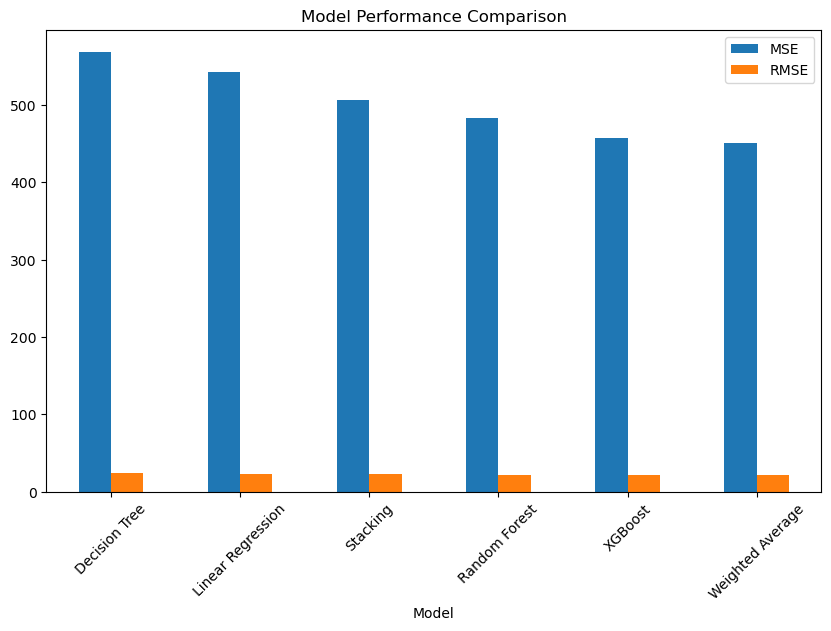

In [47]:
plot_df = results.set_index('Model')[['MSE', 'RMSE']]

plot_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()

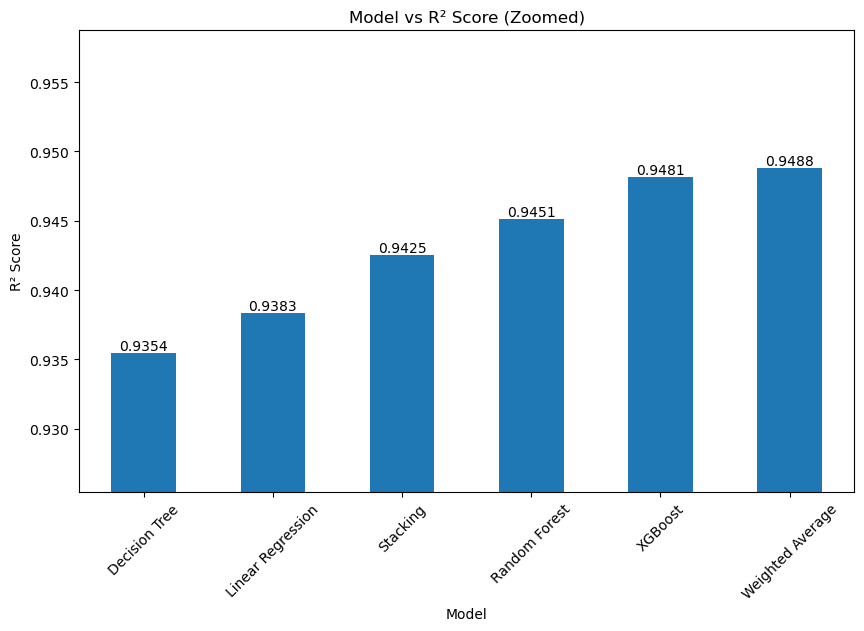

In [48]:
plot_df = results.set_index('Model')[['R2 Score']]

ax = plot_df.plot(kind='bar', figsize=(10,6), legend=False)

# Zoom into the range of your R² values
min_val = plot_df['R2 Score'].min()
max_val = plot_df['R2 Score'].max()
plt.ylim(min_val - 0.01, max_val + 0.01)

# Add labels
for i, v in enumerate(plot_df['R2 Score']):
    ax.text(i, v, f"{v:.4f}", ha='center', va='bottom')

plt.title("Model vs R² Score (Zoomed)")
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.show()

### Function creation for unseen data

In [49]:
def preprocess_single_input(row: dict) -> pd.Series:
    row = row.copy()


    row['temp_dewp_diff'] = row['TEMP'] - row['DEWP']
    row['wind_pressure']  = row['Iws'] * row['PRES']

    cbwd = row.pop('cbwd')
    row['wind_NW'] = int(cbwd == 'NW')
    row['wind_SE'] = int(cbwd == 'SE')
    row['wind_cv'] = int(cbwd == 'cv')


    return pd.Series(row)

In [50]:
def predict_with_lags(raw_input: dict, lag1: float, lag2: float, roll_mean: float) -> float:
    """
    raw_input : dict with sensor fields (year, month, day, hour, DEWP, TEMP, PRES, cbwd, Iws, Is, Ir)
    lag1      : actual pm2.5 value from 1 hour ago  (original scale, NOT log)
    lag2      : actual pm2.5 value from 2 hours ago (original scale, NOT log)
    roll_mean : mean of actual pm2.5 from last 3 hours (original scale, NOT log)

    Returns   : predicted pm2.5 in actual scale (µg/m³)
    """
    processed = preprocess_single_input(raw_input)

    # Convert user-supplied lags to log scale (same as training)
    processed['pm2.5_lag1']      = np.log1p(lag1)
    processed['pm2.5_lag2']      = np.log1p(lag2)
    processed['pm2.5_roll_mean'] = roll_mean

    X = pd.DataFrame([processed])

    # ✅ Enforce exact column order as training
    X = X[X_train.columns]

    pred_log = (0.7 * np.expm1(best_xgb.predict(X)) +
                0.2 * np.expm1(best_rf.predict(X))  +
                0.1 * np.expm1(stack_model.predict(X)))

    return float(pred_log[0])

In [51]:
import numpy as np

def get_user_input():
    print("\nEnter current weather conditions:\n")

    year  = int(input("Year (e.g., 2013): "))
    month = int(input("Month (1-12): "))
    day   = int(input("Day (1-31): "))
    hour  = int(input("Hour (0-23): "))

    dewp  = float(input("Dew Point (DEWP): "))
    temp  = float(input("Temperature (TEMP): "))
    pres  = float(input("Pressure (PRES): "))

    cbwd  = input("Wind Direction (NE, NW, SE, SW, cv): ").strip()

    iws   = float(input("Wind Speed (Iws): "))
    Is    = float(input("Snow hours (Is): "))
    Ir    = float(input("Rain hours (Ir): "))

    print("\nEnter last 3 hours PM2.5 values:\n")

    lag1 = float(input("PM2.5 (1 hour ago): "))
    lag2 = float(input("PM2.5 (2 hours ago): "))
    lag3 = float(input("PM2.5 (3 hours ago): "))

    lags = [lag1, lag2, lag3]
    log_lags = [np.log1p(x) for x in lags]
    
    roll_mean = np.mean(log_lags)
    

    new_reading = {
        'year': year, 'month': month, 'day': day, 'hour': hour,
        'DEWP': dewp, 'TEMP': temp, 'PRES': pres,
        'cbwd': cbwd, 'Iws': iws, 'Is': Is, 'Ir': Ir
    }

    return new_reading, lag1, lag2, roll_mean


# ---- Run prediction ----
new_reading, lag1, lag2, roll_mean = get_user_input()

pred = predict_with_lags(
    raw_input=new_reading,
    lag1=lag1,
    lag2=lag2,
    roll_mean=roll_mean
)

print(f"\nPredicted PM2.5 = {pred:.2f} µg/m³")


Enter current weather conditions:



Year (e.g., 2013):  2014
Month (1-12):  10
Day (1-31):  8
Hour (0-23):  11
Dew Point (DEWP):  11
Temperature (TEMP):  17
Pressure (PRES):  1020
Wind Direction (NE, NW, SE, SW, cv):  SE
Wind Speed (Iws):  1.79
Snow hours (Is):  0
Rain hours (Ir):  0



Enter last 3 hours PM2.5 values:



PM2.5 (1 hour ago):  236
PM2.5 (2 hours ago):  224
PM2.5 (3 hours ago):  243



Predicted PM2.5 = 233.07 µg/m³
